In [35]:
# ==============================================================================
# [ CELDA 1 ] : IMPORTS, STYLE & CORE FUNCTIONS
# ==============================================================================
%matplotlib widget
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. STYLE CONFIGURATION ---
poster_style = {
    "figsize": (4, 4), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.0,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# --- 2. PIPELINE FUNCTIONS ---
def TrimSpectra(spectra_input, xmin, xmax):
    trimmed = {}
    for name, df in spectra_input.items():
        mask = (df["RamanShift"] >= xmin) & (df["RamanShift"] <= xmax)
        trimmed[name] = df[mask].copy().reset_index(drop=True)
    return trimmed

def NormalizeSpectra(spectra_input, xmin=None, xmax=None, mode="M"):
    normalized = {}
    for name, df in spectra_input.items():
        df_norm = df.copy()
        X = df_norm["RamanShift"].values
        Y = df_norm["Intensity"].values
        
        if xmin is not None and xmax is not None:
            mask = (X >= xmin) & (X <= xmax)
        else:
            mask = np.ones_like(X, dtype=bool)
            
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0: continue
            
        if mode.upper() == "M": factor = np.max(Y_window)
        elif mode.upper() == "I": factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V": factor = np.min(Y_window)
        else: raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0: continue
        df_norm["Intensity"] = Y / factor
        normalized[name] = df_norm
    return normalized

def PlotRaman(
        spectra_dict, spectra_names, style=poster_style, offset_step=0.0, 
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel="Raman shift (cm$^{-1}$)", ylabel="Intensity (a.u.)",
        custom_labels=None, custom_colors=None, custom_linestyles=None, 
        vlines=None, hide_yticks=False, legend_ncol=1
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict: continue
            
        df = spectra_dict[name]
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        X = df["RamanShift"].values
        Y = df["Intensity"].values + (i * offset_step)
        
        c = custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)]
        ls = custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)]
        
        ax1.plot(X, Y, label=label, linewidth=style["line_width"], color=c, linestyle=ls)

    ax1.set_xlabel(xlabel, fontsize=style["label_size"])
    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if vlines is not None:
        for x_val in vlines:
            ax1.axvline(x=x_val, linewidth=0.5, linestyle='--', color='black', alpha=0.7, zorder=0)
            
    ax1.legend(fontsize=style["legend_size"], ncol=legend_ncol)
    plt.tight_layout()
    plt.show()

# --- 3. THE WRAPPER FUNCTION ---
def PlotRamanConfig(config, spectra_dict, offset_step=0.0, 
                    xmin=None, xmax=None, ymin=None, ymax=None, 
                    norm_xmin=None, norm_xmax=None, norm_mode="M",
                    hide_yticks=False, legend_ncol=1, vlines=None, style=poster_style):
    
    selected_list = [item[0] for item in config]
    clean_labels = [item[1] for item in config]
    custom_colors = [item[2] for item in config]
    custom_linestyles = [item[3] for item in config]
    
    selected_spectra = {name: spectra_dict[name] for name in selected_list if name in spectra_dict}
    selected_spectra = NormalizeSpectra(selected_spectra, xmin=norm_xmin, xmax=norm_xmax, mode=norm_mode)
    
    PlotRaman(
        spectra_dict=selected_spectra, 
        spectra_names=selected_list,
        custom_labels=clean_labels,
        custom_colors=custom_colors,
        custom_linestyles=custom_linestyles,
        offset_step=offset_step,
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        style=style, hide_yticks=hide_yticks, 
        legend_ncol=legend_ncol, vlines=vlines
    )



In [36]:
# ==============================================================================
# [ CELDA 2 ] : LOAD DATA (Directorio 20260818)
# ==============================================================================

target_dirs = [
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260909_FilledCNTs_InitialTest_Cl2@P2_Cl2@NI"
]

raman_spectra = {}

for folder in target_dirs:
    print(f"\nReading folder: {folder}")
    for root, dirs, files in os.walk(folder):
        for file in files:
            if not file.lower().endswith(".txt"): continue
            path = os.path.join(root, file)
            
            try:
                df = pd.read_csv(path, sep="\t", comment="#", header=None, encoding="latin1", usecols=[0, 1])
                df.columns = ["RamanShift", "Intensity"]
                df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
                df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
                df = df.dropna().sort_values("RamanShift").reset_index(drop=True)
                
                raman_spectra[file] = df
            except Exception as e:
                pass
                
print(f"Loaded {len(raman_spectra)} spectra successfully.")

for i in raman_spectra:
    print(i)



Reading folder: H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260909_FilledCNTs_InitialTest_Cl2@P2_Cl2@NI
Loaded 19 spectra successfully.
260909_Cl2@NI_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@NI_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@P2_532 nm_1200gr_x50 LD_1%_4_5_100_300_sc1400.txt
260909_Cl2@P2_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@P2_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_P2_532 nm_1200gr_x50 LD_1%_4_15_100_300_sc1400.txt
260909_P2_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@NI_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt
260909_Cl2@P2_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@P2_B_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2@P2_NoCover_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt
260909_NI_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt
260909_P2_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt
260909_P2_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
260909_Cl2

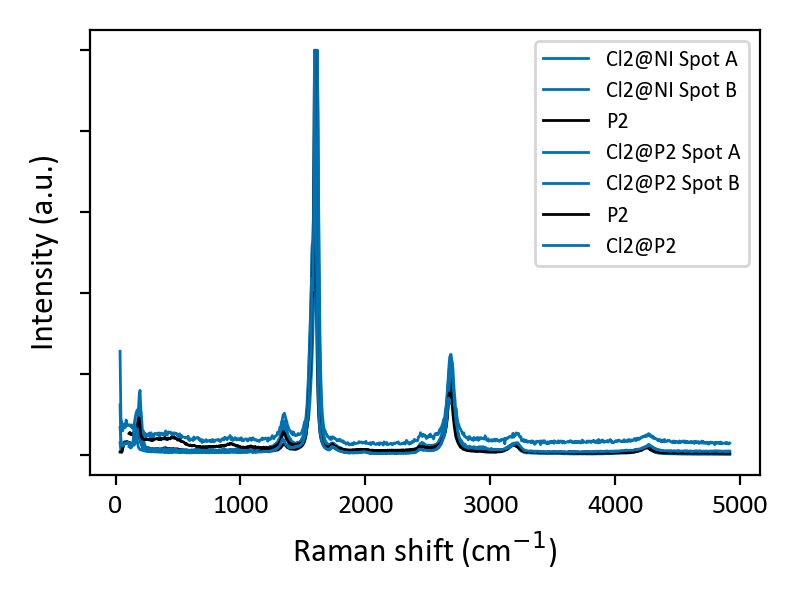

In [37]:
# ==============================================================================
###532nm
# ==============================================================================

poster_style = {
    "figsize": (4,3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 200,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

####ALLL
#260909_Cl2@NI_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@NI_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#Forgot to measure NI alone at 532 but there were not changes anyways.

#260909_P2_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt

#260909_P2_532 nm_1200gr_x50 LD_1%_4_15_100_300_sc1400.txt
#260909_Cl2@P2_532 nm_1200gr_x50 LD_1%_4_5_100_300_sc1400.txt



#260909_NI_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt
#260909_Cl2@NI_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt

#260909_P2_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_B_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt

#260909_P2_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt
#260909_Cl2@P2_NoCover_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt


#260909_NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_NI_B_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_C_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#P2 filled did not have signal at 785nm

NI_P2_532nm = [
    #NO PLOT WITH NO NI----------------------------------------------------------------------------------------
    ('260909_Cl2@NI_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@NI Spot A', "#0072B2", "-"),
    ('260909_Cl2@NI_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@NI Spot B', "#0072B2", "-"),

    #FOR PLOT 1-----------------------------------------------------------------------------------------------
    ('260909_P2_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'P2', "#000000", "-"),
    ('260909_Cl2@P2_A_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@P2 Spot A', "#0072B2", "-"),
    ('260909_Cl2@P2_B_532 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@P2 Spot B', "#0072B2", "-"),

    #FOR PLOT 2-----------------------------------------------------------------------------------------------
    ('260909_P2_532 nm_1200gr_x50 LD_1%_4_15_100_300_sc1400.txt', 'P2', "#000000", "-"),
    ('260909_Cl2@P2_532 nm_1200gr_x50 LD_1%_4_5_100_300_sc1400.txt', 'Cl2@P2', "#0072B2", "-"),


]

PlotRamanConfig(config=NI_P2_532nm, 
                spectra_dict=raman_spectra, 
                hide_yticks=True, 
                style=poster_style,
                offset_step=-0.00,
                xmin=None,
                xmax=None)



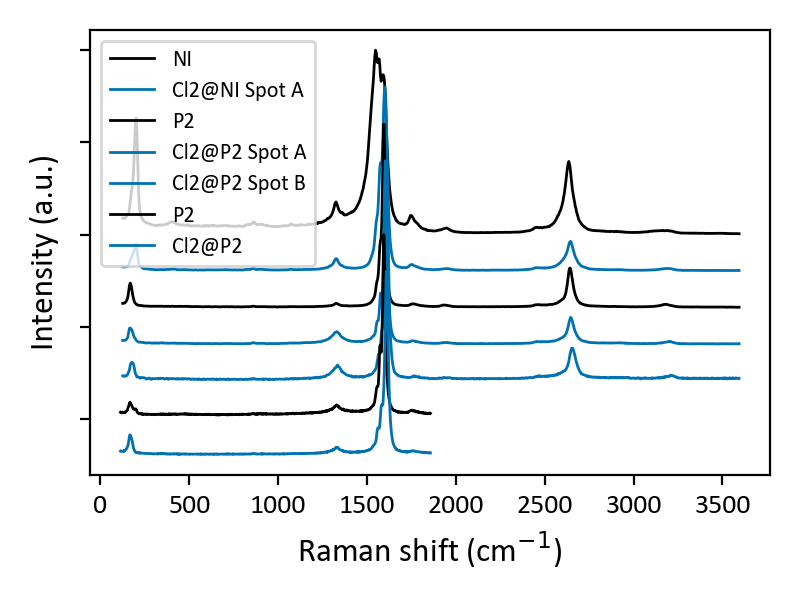

In [38]:
# ==============================================================================
###532nm
# ==============================================================================

poster_style = {
    "figsize": (4,3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 200,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

####ALLL
#260909_NI_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt
#260909_Cl2@NI_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt

#260909_P2_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt
#260909_Cl2@P2_B_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt

#260909_P2_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt
#260909_Cl2@P2_NoCover_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt


#260909_NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_NI_B_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_C_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#P2 filled did not have signal at 785nm

NI_P2_638nm = [
    #FOR PLOT 1----------------------------------------------------------------------------------------
    ('260909_NI_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt', 'NI', "#000000", "-"),
    ('260909_Cl2@NI_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc1950.txt', 'Cl2@NI Spot A', "#0072B2", "-"),

    #FOR PLOT 2-----------------------------------------------------------------------------------------------
    ('260909_P2_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'P2', "#000000", "-"),
    ('260909_Cl2@P2_A_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@P2 Spot A', "#0072B2", "-"),
    ('260909_Cl2@P2_B_638 nm_600gr_x50 LD_1%_5_5_100_300_sc2660.txt', 'Cl2@P2 Spot B', "#0072B2", "-"),

    #FOR PLOT 3-----------------------------------------------------------------------------------------------
    ('260909_P2_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt', 'P2', "#000000", "-"),
    ('260909_Cl2@P2_NoCover_638 nm_1200gr_x50 LD_1%_4_15_100_300_sc980.txt', 'Cl2@P2', "#0072B2", "-"),


]

PlotRamanConfig(config=NI_P2_638nm, 
                spectra_dict=raman_spectra, 
                hide_yticks=True, 
                style=poster_style,
                offset_step=-0.20,
                xmin=None,
                xmax=None,
                #norm_xmin=1000, norm_xmax=2000, norm_mode="I"
                )



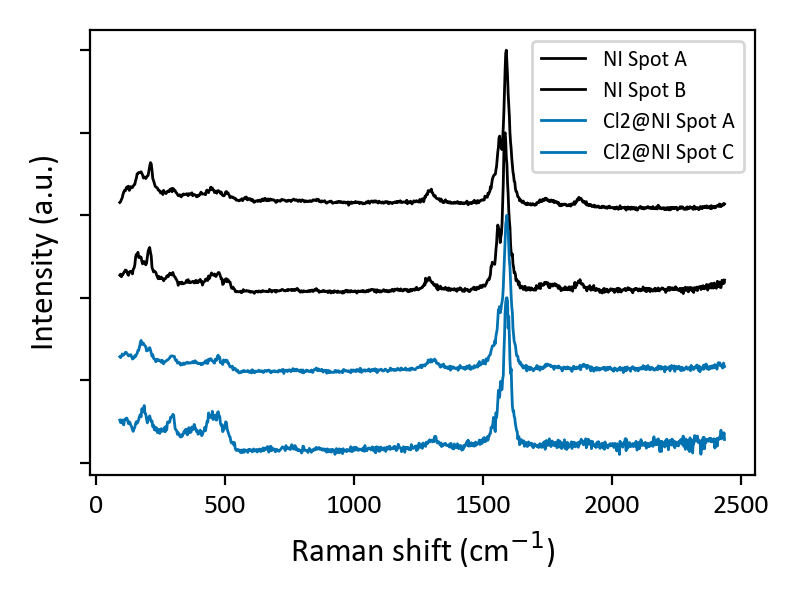

In [39]:
# ==============================================================================
###532nm
# ==============================================================================

poster_style = {
    "figsize": (4,3), # Ligeramente más grande para que quepan bien las leyendas
    "dpi": 200,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1,
    "font_family": "Calibri",
    "grid": False,                
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

####ALLL
#260909_NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_NI_B_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#260909_Cl2@NI_C_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt
#P2 filled did not have signal at 785nm

NI_P2_638nm = [
    #FOR PLOT 1----------------------------------------------------------------------------------------
    ('260909_NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt', 'NI Spot A', "#000000", "-"),
    ('260909_NI_B_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt', 'NI Spot B', "#000000", "-"),
    ('260909_Cl2@NI_A_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt', 'Cl2@NI Spot A', "#0072B2", "-"),
    ('260909_Cl2@NI_C_785 nm_600gr_x50 LD_10%_3_10_200_500_sc1300.txt', 'Cl2@NI Spot C', "#0072B2", "-"),
]

PlotRamanConfig(config=NI_P2_638nm, 
                spectra_dict=raman_spectra, 
                hide_yticks=True, 
                style=poster_style,
                offset_step=-0.5,
                xmin=None,
                xmax=None,
                #norm_xmin=1000, norm_xmax=2000, norm_mode="I"
                )

